In [2]:
def calculate_ik_leg4(x, y, z):
    """
    Calculates joint angles for Leg 4 (on -Y axis) given a target (x,y,z) in Body Frame.
    x, y, z: Coordinates in Body Frame.
    Returns: (theta_hip, theta_femur, phi2_internal) in Radians.
    """
    
    # 1. Hip Angle (Yaw)
    # Leg 4 lies on -Y axis (180 deg).
    # Calculate global angle
    theta_raw = np.arctan2(y, x)
    
    # Relative angle = Global - Mount
    theta_hip = theta_raw - MOUNT_ANGLE
    
    # Normalize to [-PI, PI]
    while theta_hip <= -np.pi: theta_hip += 2*np.pi
    while theta_hip > np.pi: theta_hip -= 2*np.pi
    
    # 2. Planar Distance Components
    # Distance from body center to target on XY plane
    r_total = np.sqrt(x**2 + y**2)
    
    # Distance from Knee Pivot to Target (Projected)
    r_eff = r_total - BODY_RADIUS - L_COXA
    
    # 3. IK for Femur and Tibia (Vertical Plane)
    # Virtual link length (Hypotenuse)
    L_virtual = np.sqrt(r_eff**2 + z**2)
    
    # Reachability Check
    if L_virtual > (L_FEMUR + L_TIBIA):
        print("Warning: Target out of reach. Clamping.")
        L_virtual = L_FEMUR + L_TIBIA
        
    # Alpha (Angle of virtual link from horizon)
    alpha_global = np.arctan2(z, r_eff)
    
    # Law of Cosines for Knee (phi1)
    cos_phi1 = (L_virtual**2 + L_FEMUR**2 - L_TIBIA**2) / (2 * L_virtual * L_FEMUR)
    cos_phi1 = np.clip(cos_phi1, -1.0, 1.0)
    phi1 = np.arccos(cos_phi1)
    
    # Law of Cosines for Foot (phi2 - Internal Angle)
    cos_phi2 = (L_FEMUR**2 + L_TIBIA**2 - L_virtual**2) / (2 * L_FEMUR * L_TIBIA)
    cos_phi2 = np.clip(cos_phi2, -1.0, 1.0)
    phi2 = np.arccos(cos_phi2) # Internal angle
    
    # Theta Femur (Pitch from Horizon)
    # Standard: Knee Up -> theta = alpha + phi1
    theta_femur = alpha_global + phi1
    
    return theta_hip, theta_femur, phi2

In [3]:
def calculate_fk_leg4(theta_hip, theta_femur, phi2):
    """
    Calculates 3D coordinates of leg joints based on angles.
    Returns list of points: [BodyCenter, HipJoint, KneeJoint, FootJoint, FootTip]
    """
    points = []
    
    # 1. Body Center
    p0 = np.array([0.0, 0.0, 0.0])
    points.append(p0)
    
    # 2. Hip Joint (Body Radius at Mount Angle)
    # This point is fixed relative to body
    hip_x = BODY_RADIUS * np.cos(MOUNT_ANGLE)
    hip_y = BODY_RADIUS * np.sin(MOUNT_ANGLE)
    hip_z = 0.0
    p1 = np.array([hip_x, hip_y, hip_z])
    points.append(p1)
    
    # Global Yaw of the leg = Mount Angle + Hip Angle
    global_yaw = MOUNT_ANGLE + theta_hip
    
    # 3. Knee Joint
    # Displaced by Coxa Length in direction of Global Yaw (Horizontal)
    knee_x = hip_x + L_COXA * np.cos(global_yaw)
    knee_y = hip_y + L_COXA * np.sin(global_yaw)
    knee_z = hip_z # Coxa is flat
    p2 = np.array([knee_x, knee_y, knee_z])
    points.append(p2)
    
    # 4. Foot Joint
    # Displaced by Femur Length.
    # Orientation: Yaw = global_yaw, Pitch = theta_femur
    # Projected length on plane = L_FEMUR * cos(theta_femur)
    # Z component = L_FEMUR * sin(theta_femur)
    femur_proj = L_FEMUR * np.cos(theta_femur)
    
    foot_x = knee_x + femur_proj * np.cos(global_yaw)
    foot_y = knee_y + femur_proj * np.sin(global_yaw)
    foot_z = knee_z + L_FEMUR * np.sin(theta_femur)
    p3 = np.array([foot_x, foot_y, foot_z])
    points.append(p3)
    
    # 5. Foot Tip
    # Angle of Tibia relative to horizon?
    # phi2 is internal angle between Femur and Tibia.
    # Angle of Tibia = theta_femur - (180 - phi2) ?
    # Let's verify: 
    # If phi2 = 180 (Straight), Tibia angle = theta_femur.
    # If phi2 = 90 (Down), Tibia angle = theta_femur - 90.
    # Formula: theta_tibia = theta_femur - (np.pi - phi2)
    theta_tibia = theta_femur - (np.pi - phi2)
    
    tibia_proj = L_TIBIA * np.cos(theta_tibia)
    
    tip_x = foot_x + tibia_proj * np.cos(global_yaw)
    tip_y = foot_y + tibia_proj * np.sin(global_yaw)
    tip_z = foot_z + L_TIBIA * np.sin(theta_tibia)
    p4 = np.array([tip_x, tip_y, tip_z])
    points.append(p4)
    
    return np.array(points)

Target (Body Frame): (0, -220.5, -152.0)

Calculated Angles (Degrees):
Hip Local Yaw:   0.00
Femur Pitch:     -32.13
Internal Knee:   126.23

FK Result Tip:   (0.00, -220.50, -152.00)
Error:           (0.00, 0.00, 0.00)


TypeError: Axes3D.plot() missing 2 required positional arguments: 'xs' and 'ys'

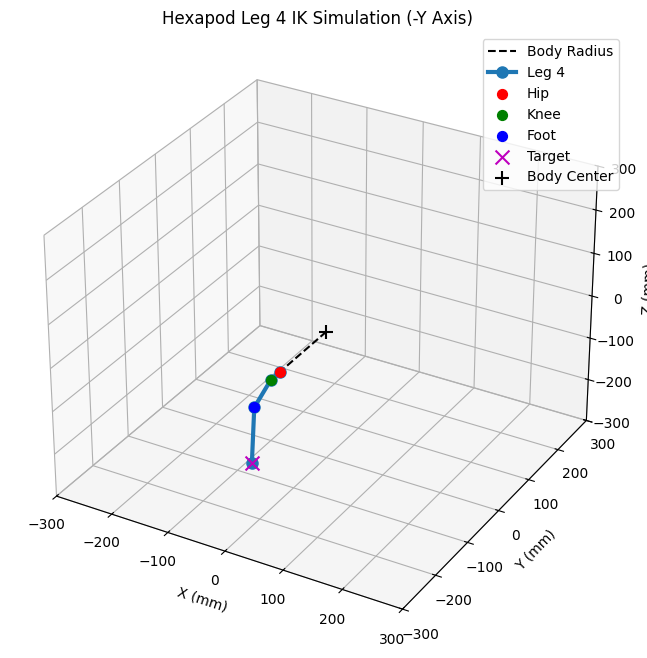

In [6]:
target_x = 0
target_y = -220.5
target_z = -152.0 # Deep reach

print(f"Target (Body Frame): ({target_x}, {target_y}, {target_z})")

# 1. Calculate IK
theta_hip, theta_femur, phi2 = calculate_ik_leg4(target_x, target_y, target_z)

print("\nCalculated Angles (Degrees):")
print(f"Hip Local Yaw:   {np.degrees(theta_hip):.2f}")
print(f"Femur Pitch:     {np.degrees(theta_femur):.2f}")
print(f"Internal Knee:   {np.degrees(phi2):.2f}")

# 2. Calculate FK for Visualization
points = calculate_fk_leg4(theta_hip, theta_femur, phi2)

tip = points[-1]
print(f"\nFK Result Tip:   ({tip[0]:.2f}, {tip[1]:.2f}, {tip[2]:.2f})")
print(f"Error:           ({tip[0]-target_x:.2f}, {tip[1]-target_y:.2f}, {tip[2]-target_z:.2f})")

# 3. Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Leg Segments
# Body to Hip
ax.plot(points[0:2,0], points[0:2,1], points[0:2,2], 'k--', label='Body Radius')
# Leg Links
ax.plot(points[1:,0], points[1:,1], points[1:,2], 'o-', linewidth=3, markersize=8, label='Leg 4')

# Highlight Joints
ax.scatter(points[1,0], points[1,1], points[1,2], s=50, c='r', label='Hip')
ax.scatter(points[2,0], points[2,1], points[2,2], s=50, c='g', label='Knee')
ax.scatter(points[3,0], points[3,1], points[3,2], s=50, c='b', label='Foot')

# Plot Target
ax.scatter(target_x, target_y, target_z, s=100, c='m', marker='x', label='Target')

# Plot Body Center
ax.scatter(0, 0, 0, s=100, c='k', marker='+', label='Body Center')

# Styling
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title('Hexapod Leg 4 IK Simulation (-Y Axis)')

# Set equal aspect ratio (roughly)
limit = 300
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)

ax.legend()
plt.plot()